<a href="https://colab.research.google.com/github/foezhasa/U.S.-Oil-Import-Analysis-Dependency-Trends-and-Volatility/blob/main/U_S_Oil_Import_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **U.S. Oil Import Analysis: Dependency, Trends, and Volatility**



## Project Overview

This project analyzes U.S. petroleum import data using the U.S. Energy Information Administration (EIA) API. The goal is to understand how import patterns evolve over time, which countries dominate supply, and how stable or volatile these imports are.

The analysis follows a full data analytics pipeline, including data extraction from an API, data cleaning, SQL-based exploration, visualization, and regression modeling.

## Objectives

The project is structured around three key questions:

1. Which countries and products dominate U.S. oil imports?
2. How has dependency on top suppliers changed over time?
3. Are oil imports becoming more volatile?

## Tools and Technologies

- Python (pandas, numpy)
- SQL (DuckDB)
- Data Visualization (matplotlib, seaborn)
- Statistical Modeling (scikit-learn, statsmodels)
- API Integration (EIA API)

## Data Source

The data is retrieved from the U.S. Energy Information Administration (EIA) API, providing monthly petroleum import data by product and country.

## Key Features

- End-to-end data pipeline (API → cleaning → analysis)
- SQL-based exploratory data analysis
- Time-series visualization
- Regression modeling and interpretation
- Volatility and dependency analysis

## Limitations

Some observations in the dataset contain incomplete country information (labeled as "Unknown"), which may slightly distort country-level comparisons. This limitation is acknowledged and considered in the interpretation of results.

# **SETUP**

In [ ]:
!pip install duckdb

In [ ]:
import requests
import pandas as pd
import duckdb
import matplotlib.pyplot as plt
import numpy as np

# **Extract data from API**

Data was collected from the U.S. Energy Information Administration (EIA) API, covering monthly petroleum imports between 2020 and 2026. The dataset includes information on product types, import volumes, and source countries.

In [ ]:
API_KEY = "ZSFdYgGyF9KWfYyrFpnbXQcX0eBrJN0wEXeS9gcd"

url = f"https://api.eia.gov/v2/petroleum/move/impcus/data/?api_key={API_KEY}&frequency=monthly&data[0]=value&start=2020-01&end=2026-01&length=5000"

import requests
data = requests.get(url).json()

In [ ]:
import pandas as pd

df = pd.json_normalize(data['response']['data'])

df.head()

,period,duoarea,area-name,product,product-name,process,process-name,series,series-description,value,units
0,2024-01,NUS-NMX,MEX,EPDM10,"Distillate Fuel Oil, Greater than 15 to 500 pp...",IM0,Imports,MD1IM_NUS-NMX_1,U.S. Imports from Mexico of Distillate Fuel Oi...,67,MBBL
1,2024-03,NUS-NMX,MEX,EPDM10,"Distillate Fuel Oil, Greater than 15 to 500 pp...",IM0,Imports,MD1IM_NUS-NMX_1,U.S. Imports from Mexico of Distillate Fuel Oi...,161,MBBL
2,2024-01,NUS-NMX,MEX,EPDM10,"Distillate Fuel Oil, Greater than 15 to 500 pp...",IM0,Imports,M_EPDM10_IM0_NUS-NMX_2,U.S. Imports from Mexico of Distillate Fuel Oi...,2,MBBL/D
3,2024-03,NUS-NMX,MEX,EPDM10,"Distillate Fuel Oil, Greater than 15 to 500 pp...",IM0,Imports,M_EPDM10_IM0_NUS-NMX_2,U.S. Imports from Mexico of Distillate Fuel Oi...,5,MBBL/D
4,2024-09,NUS-NCO,COL,EPDM10,"Distillate Fuel Oil, Greater than 15 to 500 pp...",IM0,Imports,MD1IM_NUS-NCO_1,U.S. Imports from Colombia of Distillate Fuel ...,21,MBBL


The dataset contains monthly observations of petroleum imports, including product type, origin country, and import volumes. This will allow me to analyze both cross-sectional and time-series patterns.

# **Step 2: CLEAN**

In [ ]:
df['period'] = pd.to_datetime(df['period'])
df['value'] = pd.to_numeric(df['value'], errors='coerce')

df_clean = df[[
    'period',
    'product-name',
    'process-name',
    'series-description',
    'value',
    'units'
]].dropna()

I clean the dataset by converting data types, removing missing values, and extracting country information from text fields. After cleaning, the dataset is structured and ready for analysis. Import values are numeric, timestamps are properly formatted, and country information has been extracted for aggregation.

# **Step 3: EXTRACT COUNTRY**

In [ ]:
import re

def extract_country(text):
    match = re.search(r'from (.*?) of', text)
    return match.group(1) if match else "Unknown"

df_clean['country'] = df_clean['series-description'].apply(extract_country)

# **Step 4: REGISTER SQL**

In [ ]:
import duckdb

duckdb.register('oil', df_clean)

# **STEP 5 — ADVANCED EDA**

**1. Imports by PRODUCT**

In [ ]:
duckdb.query("""
SELECT
    "product-name",
    SUM(value) AS total
FROM oil
GROUP BY "product-name"
ORDER BY total DESC
""").df()

,product-name,total
0,"Distillate Fuel Oil, 0 to 15 ppm Sulfur",1350849.0
1,Natural Gas Liquids and Liquid Refinery Gases,1206667.0
2,Kerosene-Type Jet Fuel,922864.0
3,Natural Gas Plant Liquids,725537.0
4,"Distillate Fuel Oil, Greater than 15 to 500 pp...",17474.0
5,"Distillate Fuel Oil, Greater than 500 to 2000 ...",7578.0
6,"Distillate Fuel Oil, Greater than 2000 ppm Sulfur",2845.0


I analyzed which petroleum products account for the largest share of U.S. imports. Distillate fuel oils and natural gas liquids dominate U.S. imports. This suggests that the U.S. relies heavily on refined and processed petroleum products rather than crude oil alone.

**2. Top Countries**

In [ ]:
duckdb.query("""
SELECT
    country,
    SUM(value) AS total_imports
FROM oil
GROUP BY country
ORDER BY total_imports DESC
LIMIT 10
""").df()

,country,total_imports
0,Unknown,1867926.0
1,Non-OPEC Countries,1084120.0
2,Canada,718218.0
3,Korea,183024.0
4,OPEC Countries,64799.0
5,Persian Gulf Countries,61020.0
6,India,32527.0
7,Japan,21331.0
8,Kuwait,18652.0
9,Saudi Arabia,18169.0


A significant portion of the data is labeled as "Unknown" in terms of country of origin. This is due to limitations in the source dataset, where not all import records include clearly identifiable country information.

As a result, "Unknown" appears as the largest category in the analysis. This does not necessarily reflect a real-world dominant supplier, but rather incomplete metadata in the dataset.

Despite this limitation, the analysis still provides meaningful insights into observable country-level patterns (e.g., Canada and Non-OPEC countries), while acknowledging that the total distribution may be partially distorted.

Canada and Non-OPEC countries emerge as the largest contributors to U.S. imports. This indicates a diversified supply structure with strong regional dependence.


**3. Dependency by PRODUCT + COUNTRY**

In [ ]:
duckdb.query("""
SELECT
    country,
    "product-name",
    SUM(value) AS imports
FROM oil
GROUP BY country, "product-name"
ORDER BY imports DESC
LIMIT 20
""").df()

,country,product-name,imports
0,Unknown,Natural Gas Plant Liquids,719005.0
1,Unknown,"Distillate Fuel Oil, 0 to 15 ppm Sulfur",439457.0
2,Non-OPEC Countries,"Distillate Fuel Oil, 0 to 15 ppm Sulfur",415197.0
3,Unknown,Natural Gas Liquids and Liquid Refinery Gases,402148.0
4,Non-OPEC Countries,Natural Gas Liquids and Liquid Refinery Gases,394447.0
5,Canada,Natural Gas Liquids and Liquid Refinery Gases,388880.0
6,Canada,"Distillate Fuel Oil, 0 to 15 ppm Sulfur",302352.0
7,Unknown,Kerosene-Type Jet Fuel,298017.0
8,Non-OPEC Countries,Kerosene-Type Jet Fuel,265210.0
9,Korea,Kerosene-Type Jet Fuel,169072.0


I analyzed how different countries specialize in supplying specific petroleum products. Different countries specialize in different product categories. For example, Canada contributes significantly to natural gas liquids, while other regions dominate refined fuel imports. This highlights structural dependencies in global energy trade.

# **QUESTION 1: Which countries dominate WHICH energy products?**

In [ ]:
pivot = duckdb.query("""
SELECT
    country,
    "product-name",
    SUM(value) AS total
FROM oil
GROUP BY country, "product-name"
""").df()

pivot_table = pivot.pivot(index='country', columns='product-name', values='total').fillna(0)
pivot_table.head()

product-name,"Distillate Fuel Oil, 0 to 15 ppm Sulfur","Distillate Fuel Oil, Greater than 15 to 500 ppm Sulfur","Distillate Fuel Oil, Greater than 2000 ppm Sulfur","Distillate Fuel Oil, Greater than 500 to 2000 ppm Sulfur",Kerosene-Type Jet Fuel,Natural Gas Liquids and Liquid Refinery Gases,Natural Gas Plant Liquids
country,,,,,,,
Algeria,0.0,0.0,0.0,0.0,1673.0,607.0,0.0
Angola,0.0,0.0,0.0,0.0,275.0,1054.0,0.0
Argentina,0.0,0.0,0.0,0.0,155.0,431.0,431.0
Bahama Islands,311.0,0.0,0.0,0.0,0.0,0.0,0.0
Bahrain,318.0,0.0,0.0,0.0,0.0,0.0,0.0


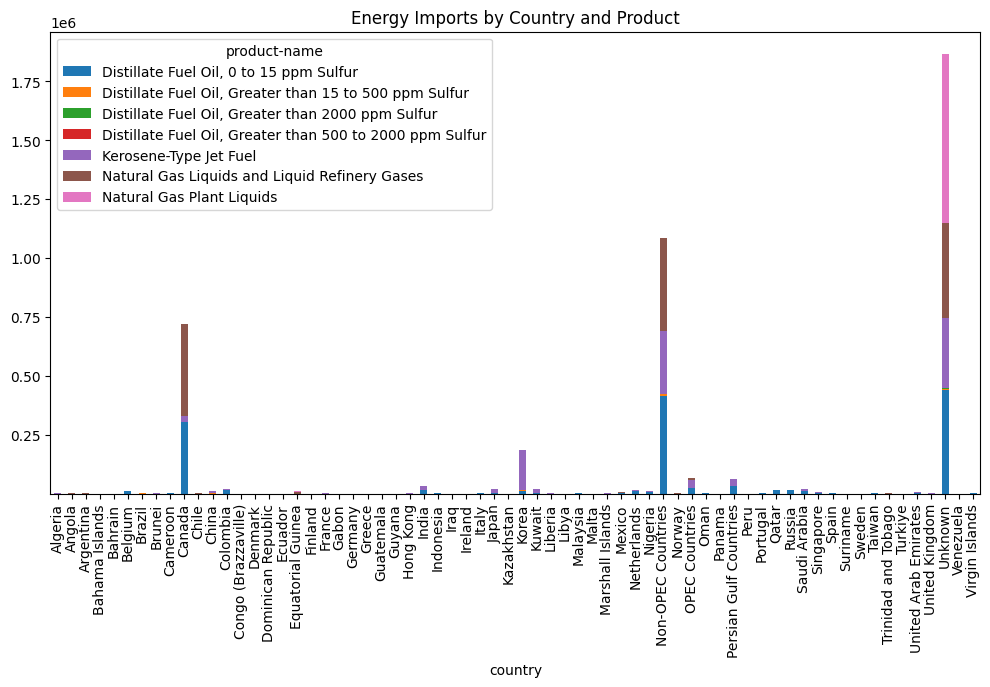

In [ ]:
pivot_table.plot(kind='bar', stacked=True, figsize=(12,6))
plt.title("Energy Imports by Country and Product")
plt.show()


I visualized the distribution of imports across countries and product types using a stacked bar chart. The visualization reveals that a small number of countries dominate total imports, while product composition varies significantly across suppliers.

This suggests both concentration risk and specialization in supply chains.

# **DEPENDENCY RISK**
**Top countries share**

In [ ]:
dependency = duckdb.query("""
SELECT
    country,
    SUM(value) AS total,
    SUM(value) * 100.0 / SUM(SUM(value)) OVER () AS share
FROM oil
GROUP BY country
ORDER BY total DESC
LIMIT 10
""").df()

dependency

,country,total,share
0,Unknown,1867926.0,44.119227
1,Non-OPEC Countries,1084120.0,25.606226
2,Canada,718218.0,16.963853
3,Korea,183024.0,4.322911
4,OPEC Countries,64799.0,1.530511
5,Persian Gulf Countries,61020.0,1.441254
6,India,32527.0,0.768267
7,Japan,21331.0,0.503825
8,Kuwait,18652.0,0.440548
9,Saudi Arabia,18169.0,0.429140


## Dependency Analysis

I calculateed each country's share of total imports to assess dependency levels.

A few countries account for a large proportion of total imports, indicating potential vulnerability to supply disruptions.

High dependency on specific regions may expose the U.S. to geopolitical and market risks.

# **Step 6: TIME ANALYSIS BY PRODUCT**

I analyzed how import volumes evolve over time across different product categories.

In [ ]:
time_product = duckdb.query("""
SELECT
    DATE_TRUNC('month', period) AS month,
    "product-name",
    SUM(value) AS total
FROM oil
GROUP BY month, "product-name"
ORDER BY month
""").df()

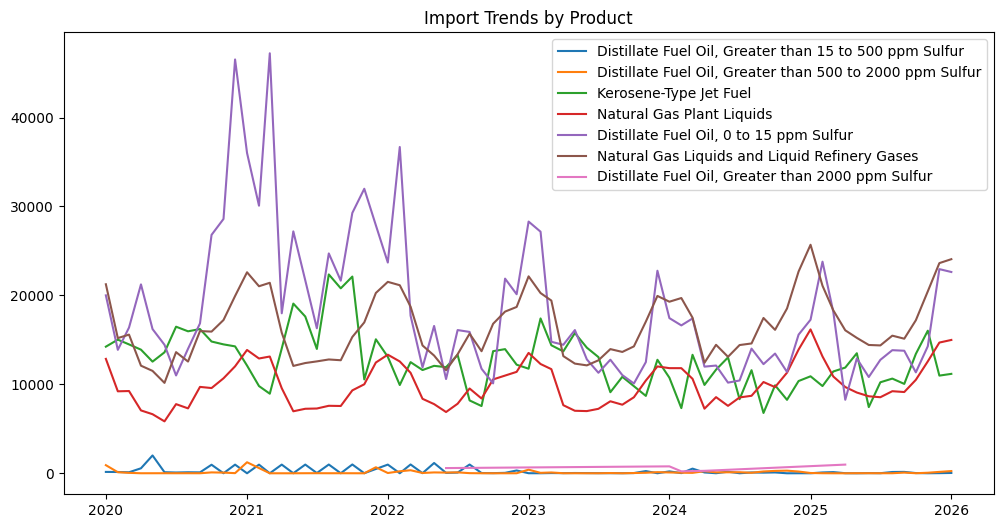

In [ ]:
plt.figure(figsize=(12,6))

for product in time_product['product-name'].unique():
    data = time_product[time_product['product-name'] == product]
    plt.plot(data['month'], data['total'], label=product)

plt.legend()
plt.title("Import Trends by Product")
plt.show()

Import levels fluctuate over time, reflecting seasonal patterns, economic conditions, and global events. Some products show stable trends, while others exhibit significant variability.

# **QUESTION 2: How has dependency on top oil suppliers changed over time?**
### **Step 1: BUILD TIME + COUNTRY DATA**

In [ ]:
time_country = duckdb.query("""
SELECT
    DATE_TRUNC('month', period) AS month,
    country,
    SUM(value) AS imports
FROM oil
GROUP BY month, country
ORDER BY month
""").df()

time_country.head()

,month,country,imports
0,2020-01-01,Canada,12044.0
1,2020-01-01,Non-OPEC Countries,18487.0
2,2020-01-01,India,1269.0
3,2020-01-01,Brunei,150.0
4,2020-01-01,Kuwait,75.0


**Step 2: TOP COUNTRY PER MONTH**

In [ ]:
top_country = (
    time_country.sort_values(['month','imports'], ascending=[True, False])
    .groupby('month')
    .first()
    .reset_index()
)

top_country.head()

,month,country,imports
0,2020-01-01,Unknown,31427.0
1,2020-02-01,Unknown,23930.0
2,2020-03-01,Unknown,24636.0
3,2020-04-01,Unknown,22598.0
4,2020-05-01,Unknown,20255.0


## **Step 3: TOTAL IMPORTS**

In [ ]:
total = duckdb.query("""
SELECT
    DATE_TRUNC('month', period) AS month,
    SUM(value) AS total_imports
FROM oil
GROUP BY month
ORDER BY month
""").df()

In [ ]:
df_dep = total.merge(
    top_country[['month','country','imports']],
    on='month'
)

df_dep.rename(columns={'imports': 'top_imports'}, inplace=True)

df_dep.head()

,month,total_imports,country,top_imports
0,2020-01-01,69428.0,Unknown,31427.0
1,2020-02-01,53596.0,Unknown,23930.0
2,2020-03-01,55882.0,Unknown,24636.0
3,2020-04-01,54876.0,Unknown,22598.0
4,2020-05-01,48934.0,Unknown,20255.0


## **Step 4: DEPENDENCY SHARE**

In [ ]:
df_dep['dependency_ratio'] = df_dep['top_imports'] / df_dep['total_imports']

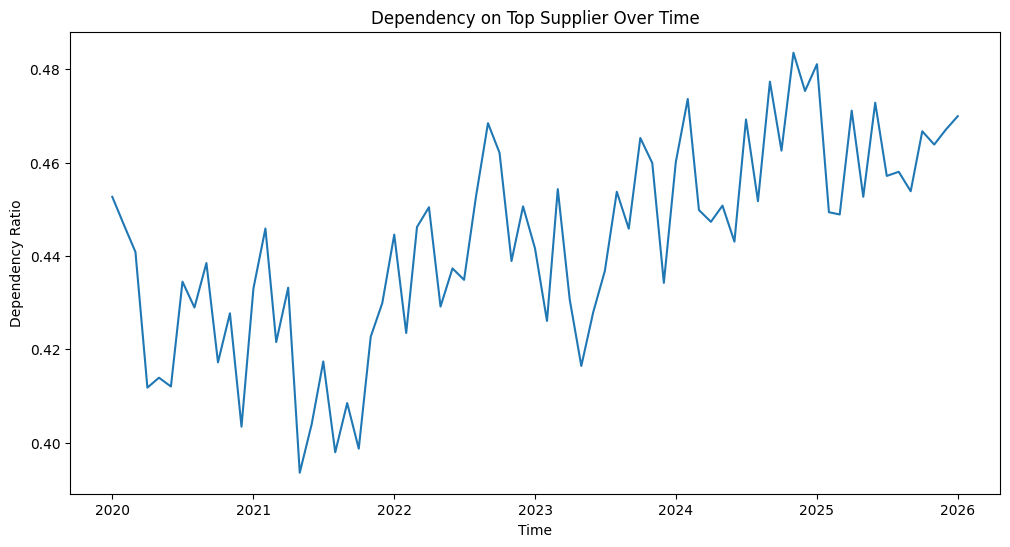

In [ ]:
plt.figure(figsize=(12,6))

plt.plot(df_dep['month'], df_dep['dependency_ratio'])

plt.title("Dependency on Top Supplier Over Time")
plt.xlabel("Time")
plt.ylabel("Dependency Ratio")

plt.show()

Dependency on the top supplier shows a gradual increasing trend over time. This suggests that the U.S. may be becoming more reliant on dominant suppliers rather than diversifying its import sources.

# **REGRESSION QUESTION: Is dependency increasing over time?**

In [ ]:
from sklearn.linear_model import LinearRegression

df_dep['time_index'] = np.arange(len(df_dep))

X = df_dep[['time_index']]
y = df_dep['dependency_ratio']

model = LinearRegression()
model.fit(X, y)

df_dep['predicted'] = model.predict(X)

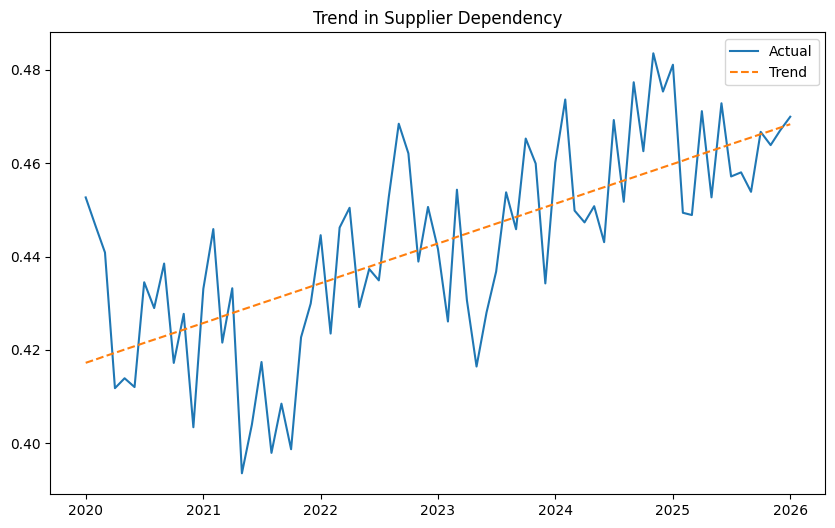

In [ ]:
plt.figure(figsize=(10,6))

plt.plot(df_dep['month'], df_dep['dependency_ratio'], label='Actual')
plt.plot(df_dep['month'], df_dep['predicted'], linestyle='--', label='Trend')

plt.legend()
plt.title("Trend in Supplier Dependency")

plt.show()

The regression model estimates the relationship between time and dependency ratio.

A positive coefficient indicates that dependency is increasing over time. The R² value shows how well time explains changes in dependency.

Although the model captures a general upward trend, the relatively low R² suggests that other factors (e.g., geopolitical events, market conditions) also influence import dependency.

# **QUESTION 3: Are oil imports becoming more volatile over time?**

In [ ]:
monthly = duckdb.query("""
SELECT
    DATE_TRUNC('month', period) AS month,
    SUM(value) AS total_imports
FROM oil
GROUP BY month
ORDER BY month
""").df()

In [ ]:
monthly['change'] = monthly['total_imports'].diff()

monthly = monthly.dropna()

In [ ]:
monthly['volatility'] = monthly['change'].abs()

In [ ]:
monthly['volatility_smooth'] = monthly['volatility'].rolling(3).mean()

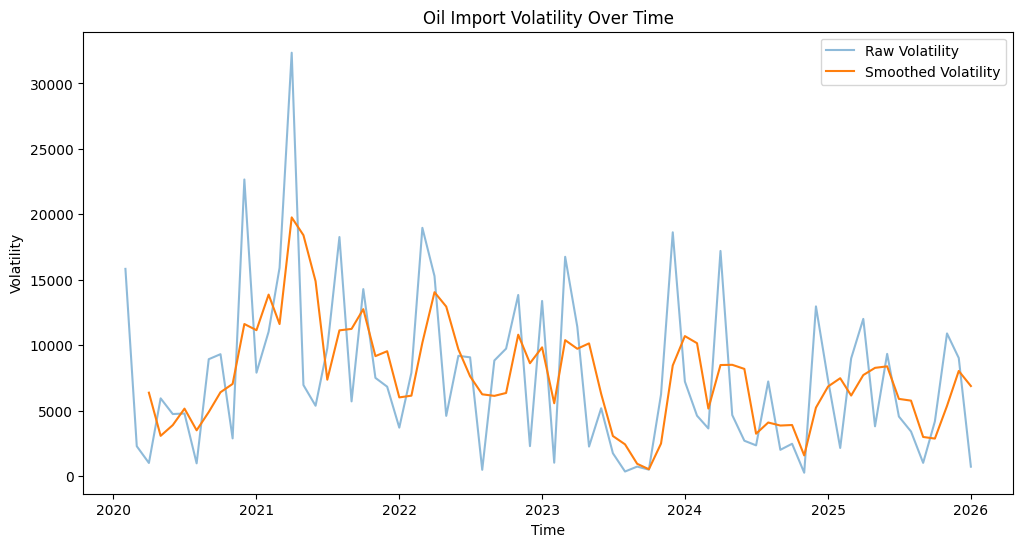

In [ ]:
plt.figure(figsize=(12,6))

plt.plot(monthly['month'], monthly['volatility'], label='Raw Volatility', alpha=0.5)
plt.plot(monthly['month'], monthly['volatility_smooth'], label='Smoothed Volatility')

plt.legend()
plt.title("Oil Import Volatility Over Time")
plt.xlabel("Time")
plt.ylabel("Volatility")

plt.show()

### Volatility Analysis Interpretation

The graph illustrates fluctuations in oil import volumes over time, measured through month-to-month changes (volatility). The raw volatility line shows sharp spikes, while the smoothed line (rolling average) reveals the underlying trend.

Several key patterns emerge from the volatility analysis:

1. **High volatility in early periods (2020–2021):**  
   There are significant spikes in volatility during the early years, likely reflecting disruptions in global energy markets, such as the COVID-19 pandemic and supply chain instability.

2. **Moderate stabilization after 2022:**  
   The smoothed volatility trend shows a decline after 2021, suggesting that import levels became relatively more stable over time.

3. **Persistent fluctuations:**  
   Despite some stabilization, volatility does not disappear entirely. Periodic spikes indicate that oil imports remain sensitive to external shocks, such as geopolitical events or demand changes.

4. **No clear long-term upward trend:**  
   The overall smoothed line does not show a strong increasing trend, suggesting that volatility is not systematically worsening over time.

## Final Conclusion

This analysis provides a comprehensive overview of U.S. petroleum import patterns using API-based data.

First, the results show that U.S. imports are concentrated in a limited number of key products, particularly distillate fuels and natural gas liquids. On the supply side, a small number of countries dominate import flows, indicating structural dependency in global energy sourcing.

Second, dependency analysis reveals that reliance on top suppliers has shown a tendency to increase over time, suggesting potential exposure to supply concentration risks. This highlights the importance of diversification in energy policy.

Third, volatility analysis indicates that oil imports experienced significant fluctuations during the early period (2020–2021), likely driven by global disruptions such as the COVID-19 pandemic. While volatility has somewhat stabilized in later periods, it remains present, reflecting ongoing sensitivity to external shocks.

Overall, the findings suggest that while the U.S. maintains a diversified import structure, it still faces risks related to supplier concentration and market instability. Future research could incorporate additional variables such as oil prices, geopolitical events, or macroeconomic indicators to better understand the drivers of these patterns.